## Data Exploration & Image pre-processing 
> Explore the dataset 

In [13]:
# Import necessary packages 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import seaborn as sns
sns.set()

# 1.Exploration 
> Read the data from csv files

In [14]:
# Read csv file containing training metadata
train_df = pd.read_csv("train-metadata.csv")
# Print first 5 rows
print(f'There are {train_df.shape[0]} rows and {train_df.shape[1]}columns in this data frame')
train_df.head()

/var/folders/18/nl99l9ns60b8w005rkqx765m0000gn/T/ipykernel_87257/1172988382.py:2: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train-metadata.csv")


There are 401059 rows and 55columns in this data frame


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


The file contains the names of skin images("image_type") and the columns with ("iddx_full") the diagnosis based on the provided image.


### 1.1 Data types and Null Values Check

In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       401059 non-null  object 
 1   target                        401059 non-null  int64  
 2   patient_id                    401059 non-null  object 
 3   age_approx                    398261 non-null  float64
 4   sex                           389542 non-null  object 
 5   anatom_site_general           395303 non-null  object 
 6   clin_size_long_diam_mm        401059 non-null  float64
 7   image_type                    401059 non-null  object 
 8   tbp_tile_type                 401059 non-null  object 
 9   tbp_lv_A                      401059 non-null  float64
 10  tbp_lv_Aext                   401059 non-null  float64
 11  tbp_lv_B                      401059 non-null  float64
 12  tbp_lv_Bext                   401059 non-nul

### 1.2 Unique IDs Check 
> "patient_id" has an identification number for each patient. To make sure if I am looking at repeated data for certain patients or whether each image represents a different person. 

In [16]:
print(f"The total patient ids are {train_df['patient_id'].count()}, from those the unique ids are {train_df['patient_id'].value_counts().shape[0]}")

The total patient ids are 401059, from those the unique ids are 1042


> For patients with multiple records, I need to make sure they don't show up in both training sets in order to avoid data leakage.


* Not very sure about the next step 

### 1.3 Data labels 
> Create a list of names of each patient condition or disease.


In [17]:
# train_df.describe()

In [18]:
columns = train_df.keys()
columns = list(columns)
print(columns)

['isic_id', 'target', 'patient_id', 'age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'image_type', 'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']


In [19]:
# Remove unnecessary elements 
columns.remove('image_type')
columns.remove('patient_id')
# Get the total classes 
print(f"There are {len(columns)} columns of labels for these conditions: {columns}")

There are 53 columns of labels for these conditions: ['isic_id', 'target', 'age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'attribution', 'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']


Number of positive labels(1's) for each condition

In [20]:
# Print the number of positive labels for each class
for column in columns:
    if pd.api.types.is_numeric_dtype(train_df[column]):
        print(f"The class {column} has {train_df[column].sum()} samples")
    else:
        print(f"The class {column} is not numeric and cannot be summed")

The class isic_id is not numeric and cannot be summed
The class target has 393 samples
The class age_approx has 23104310.0 samples
The class sex is not numeric and cannot be summed
The class anatom_site_general is not numeric and cannot be summed
The class clin_size_long_diam_mm has 1576493.62 samples
The class tbp_tile_type is not numeric and cannot be summed
The class tbp_lv_A has 8010755.191687866 samples
The class tbp_lv_Aext has 5983498.3043471 samples
The class tbp_lv_B has 11342632.81976335 samples
The class tbp_lv_Bext has 10793706.859794293 samples
The class tbp_lv_C has 13951375.29041463 samples
The class tbp_lv_Cext has 12401257.212599738 samples
The class tbp_lv_H has 21919353.914216895 samples
The class tbp_lv_Hext has 24463343.238985546 samples
The class tbp_lv_L has 16960775.639552794 samples
The class tbp_lv_Lext has 20534031.839148667 samples
The class tbp_lv_areaMM2 has 3425033.6461826516 samples
The class tbp_lv_area_perim_ratio has 7654017.141963031 samples
The clas

* Checking if dataset is balanced?!

In [21]:
# Calculate the distribution of the target variable
total_samples = len(train_df)
positive_samples = train_df['target'].sum()
negative_samples = total_samples - positive_samples

print(f"Total samples: {total_samples}")
print(f"Positive samples (target=1): {positive_samples}")
print(f"Negative samples (target=0): {negative_samples}")

# Check if the dataset is balanced
if positive_samples == negative_samples:
    print("The dataset is perfectly balanced.")
else:
    imbalance_ratio = positive_samples / total_samples
    print(f"The dataset is not balanced. The ratio of positive samples is {imbalance_ratio:.2f}.")


Total samples: 401059
Positive samples (target=1): 393
Negative samples (target=0): 400666
The dataset is not balanced. The ratio of positive samples is 0.00.


In [22]:
# 1.4 Data Visualization 


Display random Images


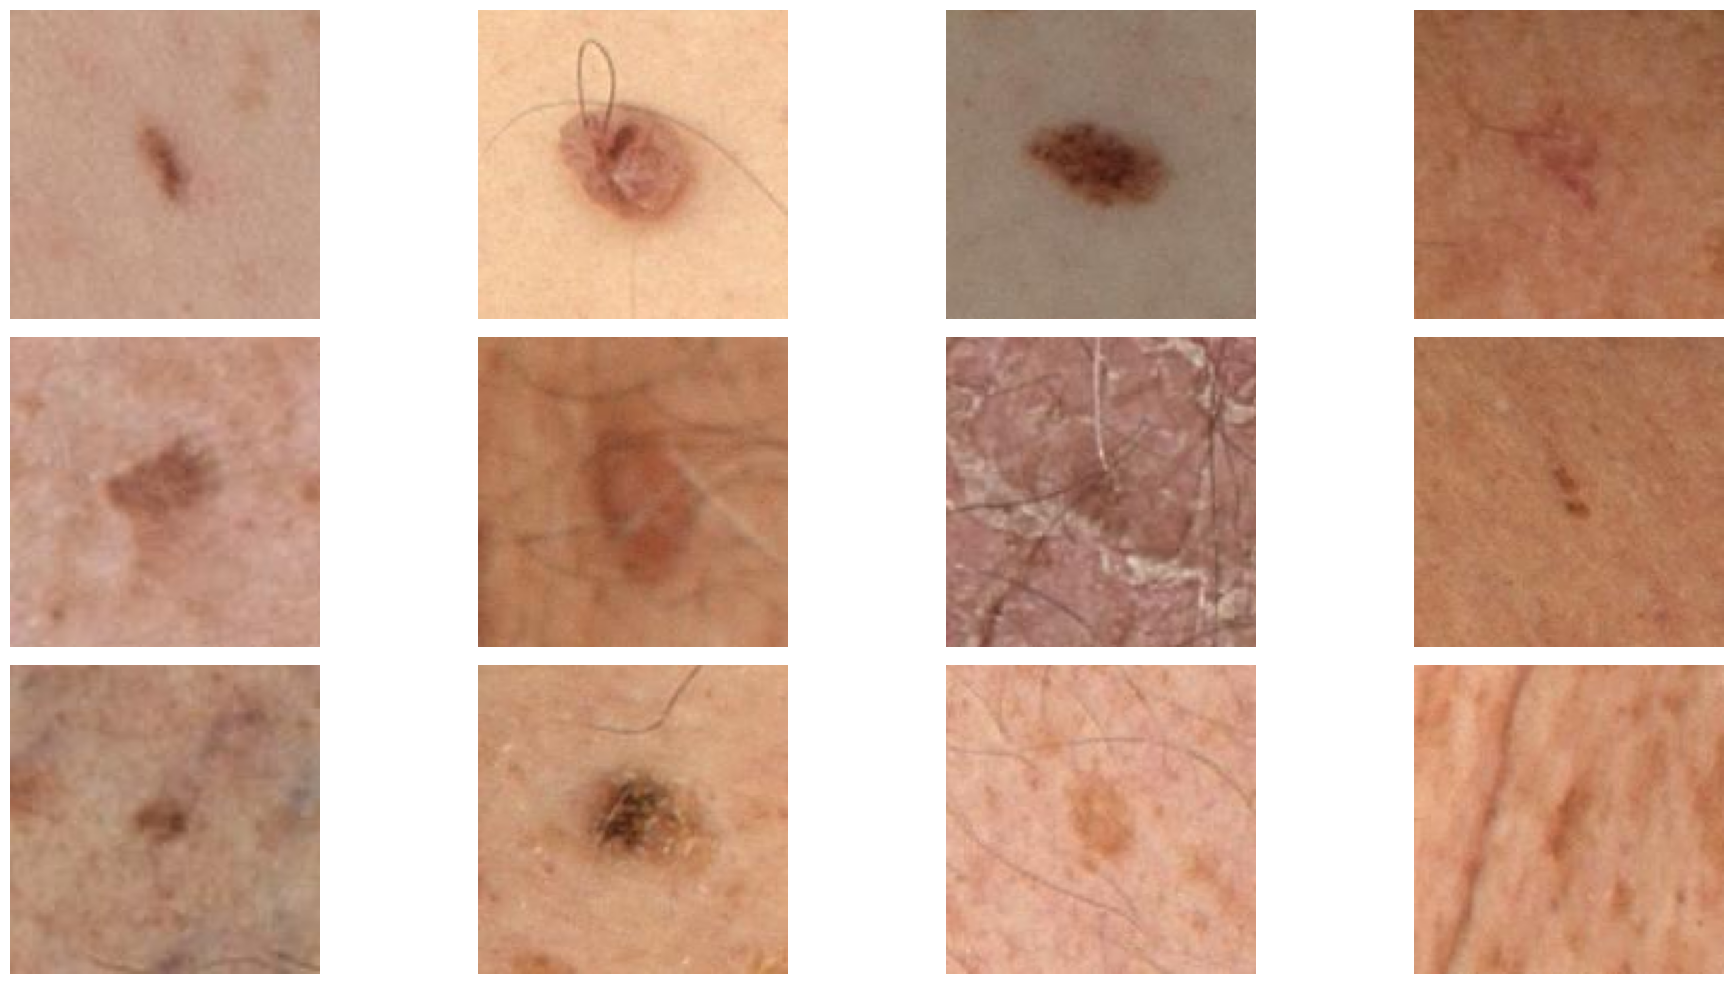

In [23]:
# Extract numpy values from image_type column in data frame 
images = train_df['isic_id'].values

# Extract 12 random images from it 
random_images = [np.random.choice(images) for i in range(12)]

# Location of the image dir
img_dir = '/Users/abdieljonathan/Desktop/isic-2024-challenge/train-image/image'


print('Display random Images')

#adjusting the size 
plt.figure(figsize=(20,10))

#Iterate and plot random images
for i in range(12):
    plt.subplot(3,4, i + 1)
    img = plt.imread(os.path.join(img_dir, f"{random_images[i]}.jpg"))
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# Adjust subplot parameters to give specified padding
plt.tight_layout() 
plt.show()

In [24]:
## 1.5 Investigating a Single Image 

The dimensions of the image are 139 pixels width and 139 pixels height, one single color channel
The maximum pixel value is 225.0000 and the minimum is 79.0000
The mean value of the pixels is 151.7888 and the standard deviation is 23.9080


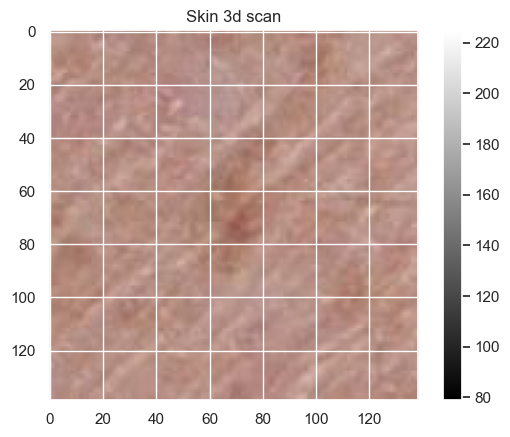

In [25]:
# Get the first image that was listed in the train_df dataframe

# Assuming 'isic_id' contains the filenames with extensions like 'ISIC_0015670.jpg'
sample_img = train_df['isic_id'][0] + '.jpg'  
# Load the image
img_path = os.path.join(img_dir, sample_img)
raw_image = plt.imread(img_path)

# Display the image
plt.imshow(raw_image, cmap='gray')
plt.colorbar()
plt.title('Skin 3d scan')

# Print image statistics
print(f"The dimensions of the image are {raw_image.shape[0]} pixels width and {raw_image.shape[1]} pixels height, one single color channel")
print(f"The maximum pixel value is {raw_image.max():.4f} and the minimum is {raw_image.min():.4f}")
print(f"The mean value of the pixels is {raw_image.mean():.4f} and the standard deviation is {raw_image.std():.4f}")


Text(0, 0.5, '# Pixels in Image')

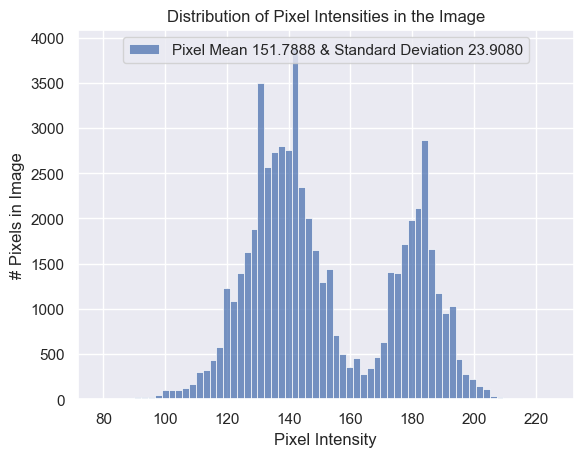

In [26]:
# Plot a histogram of the distribution of the pixels
sns.histplot(raw_image.ravel(), 
             label=f'Pixel Mean {np.mean(raw_image):.4f} & Standard Deviation {np.std(raw_image):.4f}', kde=False)
plt.legend(loc='upper center')
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixels in Image')

## 2. Image Preprocessing in Keras
> Using Keras to perform data preprocessing and data augmentation
Check those next steps

In [27]:
#Import data generator from keras 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/Users/abdieljonathan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [28]:
# Normalizing images
image_generator = ImageDataGenerator(
    samplewise_center=True, #Setting each sample mean to 0.
    samplewise_std_normalization= True # Divinding each input by its standard deviation
)

In [29]:
# Ensure isic_id values have .jpg extension
train_df['isic_id'] = train_df['isic_id'].apply(lambda x: f"{x}.jpg")

# Create an instance of ImageDataGenerator with desired preprocessing
image_generator = ImageDataGenerator(rescale=1./255)

# Flow from directory with specified batch size and target image size 
generator = image_generator.flow_from_dataframe(
    dataframe=train_df,
    directory="/Users/abdieljonathan/Desktop/isic-2024-challenge/train-image/image",
    x_col="isic_id", # using isic_id with .jpg extension
    y_col="target", # 'target' column should be in train_df
    class_mode="raw", # 'target' column should be in train_df
    batch_size=1, # images per batch
    shuffle=False, # shuffle the rows or not
    target_size=(240, 240), # width and height of output image
    validate_filenames=True # to ensure filenames are valid
)

# Verify the generator
for data_batch, labels_batch in generator:
    print(f'Data batch shape: {data_batch.shape}')
    print(f'Labels batch shape: {labels_batch.shape}')
    break

Found 401059 validated image filenames.
Data batch shape: (1, 240, 240, 3)
Labels batch shape: (1,)


### maybe change files from jpeg to hdf5 

The dimensions of the image are 240 pixels width and 240 pixels height
The maximum pixel value is 0.8824 and the minimum is 0.3098
The mean value of the pixels is 0.5953 and the standard deviation is 0.0937


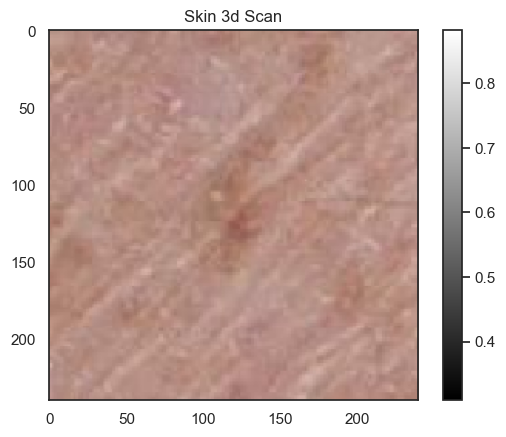

In [30]:
# Plot a processed image
sns.set_style("white")
generated_image, label = generator.__getitem__(0)
plt.imshow(generated_image[0], cmap='gray')
plt.colorbar()
plt.title('Skin 3d Scan')
print(f"The dimensions of the image are {generated_image.shape[1]} pixels width and {generated_image.shape[2]} pixels height")
print(f"The maximum pixel value is {generated_image.max():.4f} and the minimum is {generated_image.min():.4f}")
print(f"The mean value of the pixels is {generated_image.mean():.4f} and the standard deviation is {generated_image.std():.4f}")

/var/folders/18/nl99l9ns60b8w005rkqx765m0000gn/T/ipykernel_87257/3853369951.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(raw_image.ravel(),
/var/folders/18/nl99l9ns60b8w005rkqx765m0000gn/T/ipykernel_87257/3853369951.py:18: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(generated_image[0].r

Text(0, 0.5, '# Pixel')

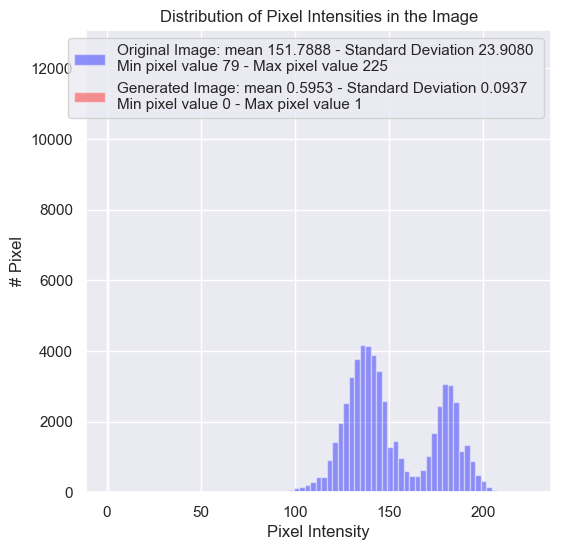

In [31]:
# Include a histogram of the distribution of the pixels
sns.set()
plt.figure(figsize=(6, 6))

# Plot histogram for original image
stats = f'mean {np.mean(raw_image):.4f} - Standard Deviation {np.std(raw_image):.4f} \n' \
       f'Min pixel value {np.min(raw_image):.0f} - Max pixel value {np.max(raw_image):.0f}'

sns.distplot(raw_image.ravel(),
             label=f'Original Image: {stats}',
             color='blue',
             kde=False)

# Plot histogram for generated image
stats = f'mean {np.mean(generated_image[0]):.4f} - Standard Deviation {np.std(generated_image[0]):.4f} \n' \
       f'Min pixel value {np.min(generated_image[0]):.0f} - Max pixel value {np.max(generated_image[0]):.0f}'

sns.distplot(generated_image[0].ravel(),
             label=f'Generated Image: {stats}',
             color='red',
             kde=False)

# Place legends
plt.legend()
plt.title('Distribution of Pixel Intensities in the Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('# Pixel')

In [32]:
# Resenet(18) / use a convulation network 
# validation 
# test 
# pass the data through it and compare 

In [33]:
# Starting the CNN to later make adjustments 
# maybe use torch.utils.data.Dataset
# torch.utils.data.Dataloader 

In [85]:
import h5py
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torchvision.transforms as transforms

# Define the dataset class
class CustomHDF5Dataset(Dataset):
    def __init__(self, image_ids, hdf5_path, transform=None):
        self.image_ids = image_ids
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.hdf5_file = h5py.File(hdf5_path, 'r')

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        image = np.array(self.hdf5_file[img_id])
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        return image

# Define transformations (optional, but recommended for normalization and augmentation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
  
    transforms.ToTensor(),
])

# Assuming you have these lists populated correctly
train_image_ids = ['ISIC_0015670', 'ISIC_0015671', 'ISIC_0015672']  # Example IDs
valid_image_ids = ['ISIC_0015673', 'ISIC_0015674']  # Example IDs
test_image_ids = ['ISIC_0015675', 'ISIC_0015676']  # Example IDs

# Initialize datasets
train_dataset = CustomHDF5Dataset(image_ids=train_image_ids, hdf5_path='train-image.hdf5', transform=transform)
valid_dataset = CustomHDF5Dataset(image_ids=valid_image_ids, hdf5_path='train-image.hdf5', transform=transform)  # Assuming same HDF5 file
test_dataset = CustomHDF5Dataset(image_ids=test_image_ids, hdf5_path='test-image.hdf5', transform=transform)

# Initialize DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=SubsetRandomSampler(range(len(train_dataset)))
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    sampler=SubsetRandomSampler(range(len(valid_dataset)))
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)


In [86]:
len(train_images)


401059

In [87]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler

# Define transformations (optional, but recommended for normalization and augmentation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Initialize datasets
train_dataset = CustomHDF5Dataset(image_ids=train_image_ids, hdf5_path='train-image.hdf5', transform=transform)
valid_dataset = CustomHDF5Dataset(image_ids=valid_image_ids, hdf5_path='valid-image.hdf5', transform=transform)
test_dataset = CustomHDF5Dataset(image_ids=test_image_ids, hdf5_path='test-image.hdf5', transform=transform)

# Initialize DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=SubsetRandomSampler(range(len(train_dataset)))
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    sampler=SubsetRandomSampler(range(len(valid_dataset)))
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'valid-image.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [88]:
len(valid_indices)

80211

In [89]:
train = SubsetRandomSampler(train_indices)
valid = SubsetRandomSampler(valid_indices)

In [90]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, sampler=train)
valid_loader = DataLoader(train_data, batch_size=32, sampler=valid)
test_loader = DataLoader(test_data, batch_size=32)

In [91]:
classes = ['isic_id', 'target', 'age_approx', 'sex', 'anatom_site_general',
           'clin_size_long_diam_mm', 'tbp_tile_type', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 
           'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence',
           'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'attribution', 
           'copyright_license', 'lesion_id', 'iddx_full', 'iddx_1', 'iddx_2', 'iddx_3', 'iddx_4', 'iddx_5', 'mel_mitotic_index', 'mel_thick_mm', 'tbp_lv_dnn_lesion_confidence']

In [92]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.linear = nn.Sequential(
            nn.Linear(4096, 128),
            nn.ReLU(),
            nn.Linear(128, len(classes))
        )
        
    def forward(self, x):
        output = self.cnn_layers(x)
        output = output.view(output.size(0), -1)
        output = self.linear(output)
        return output

In [93]:
model = CNN()
print(model)

CNN(
  (cnn_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=53, bias=True)
  )
)


In [94]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(model.parameters(), momentum=0.9, lr=0.001)

In [95]:
epochs = 5
train_loss = []
valid_loss = []

for epoch in range(epochs):
    epoch_train_loss = 0.
    model.train()
    for data in train_loader:
        # Ensure target is properly retrieved if it's not already part of the data
        data, target = data

        optimiser.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimiser.step()
        epoch_train_loss += loss.item() * data.size(0)
    
    train_loss.append(epoch_train_loss / len(train_dataset))
    
    model.eval()
    
    epoch_valid_loss = 0.
    with torch.no_grad():
        for data in valid_loader:
            # Ensure target is properly retrieved if it's not already part of the data
            data, target = data

            output = model(data)
            loss = criterion(output, target)
            epoch_valid_loss += loss.item() * data.size(0)
    
    valid_loss.append(epoch_valid_loss / len(valid_dataset))
    
    print(f'Epoch {epoch+1} - Training Loss: {train_loss[-1]:.4f}, Validation Loss: {valid_loss[-1]:.4f}')


NotADirectoryError: [Errno 20] Not a directory: 'train-image.hdf5/ISIC_2812843.jpg'